# Truncated Analysis


In [1]:
from pathlib import Path
import os
import re

import numpy as np
import pandas as pd

from HW_HD_utils import *
from plots_utils import *
from create_npy_file import create_npy_file, create_grouped_npy_files, create_npy_file_truncated


Call the directory where the traces are saved and the result directory 

In [2]:
truncated_registers = ["r2", "r3", "r4", "r5", "r6"]
truncated_trace_dir = "output_decapsulation_truncated_TRIM"
result_dir_truncated = "Results_decapsulation_truncated"
no_instructions = 100 
reset_folder(result_dir_truncated)

os.makedirs(result_dir_truncated, exist_ok=True)

create_npy_file_truncated(f"{result_dir_truncated}/HW_SUBTRACE", truncated_trace_dir, "HW", truncated_registers)
create_npy_file_truncated(f"{result_dir_truncated}/HD_SUBTRACE", truncated_trace_dir, "HD", truncated_registers)

data_HW_by_register = {}
# create one .npy file per register and per xs_id, and load them into a dictionary
for reg in truncated_registers:
    create_npy_file_truncated(
        f"{result_dir_truncated}/HW_SUBTRACE_{reg}",
        truncated_trace_dir,
        "HW",
        [reg],
    )

    data_HW_by_register[reg] = {}

    for file in sorted(Path(result_dir_truncated).glob(f"HW_SUBTRACE_{reg}_xs*.npy")):
        match = re.search(r"xs(\d+)", file.stem)
        xs = int(match.group(1))
        data_HW_by_register[reg][xs] = np.load(file)

create_npy_file_truncated(
    f"{result_dir_truncated}/HW_SUBTRACE_r0",
    truncated_trace_dir,
    "HW",
    ["r0"],
)
create_npy_file_truncated(
    f"{result_dir_truncated}/HD_SUBTRACE_r0",
    truncated_trace_dir,
    "HD",
    ["r0"],
)



Creating simulation traces model.... HW
Found 640 truncated trace files
Trace 0 has been converted
Trace row 0 for xs=0 -> trace_0_0.csv
Trace row 0 for xs=1 -> trace_0_1.csv
Trace row 0 for xs=2 -> trace_0_2.csv
Trace row 0 for xs=3 -> trace_0_3.csv
Trace row 0 for xs=4 -> trace_0_4.csv
Trace row 0 for xs=5 -> trace_0_5.csv
Trace row 0 for xs=6 -> trace_0_6.csv
Trace row 0 for xs=7 -> trace_0_7.csv
Trace row 1 for xs=0 -> trace_1_0.csv
Trace row 1 for xs=1 -> trace_1_1.csv
Trace row 1 for xs=2 -> trace_1_2.csv
Trace row 1 for xs=3 -> trace_1_3.csv
Trace row 1 for xs=4 -> trace_1_4.csv
Trace row 1 for xs=5 -> trace_1_5.csv
Trace row 1 for xs=6 -> trace_1_6.csv
Trace row 1 for xs=7 -> trace_1_7.csv
Trace row 2 for xs=0 -> trace_2_0.csv
Trace row 2 for xs=1 -> trace_2_1.csv
Trace row 2 for xs=2 -> trace_2_2.csv
Trace row 2 for xs=3 -> trace_2_3.csv
Trace row 2 for xs=4 -> trace_2_4.csv
Trace row 2 for xs=5 -> trace_2_5.csv
Trace row 2 for xs=6 -> trace_2_6.csv
Trace row 2 for xs=7 -> tra

In [3]:
data_HW_truncated = {}
print("Information HW truncated")
print("------------------------")
for file in sorted(Path(result_dir_truncated).glob("HW_SUBTRACE_xs*.npy")):
    match = re.search(r"xs(\d+)", file.stem)
    xs_id = int(match.group(1))
    data_HW_truncated[xs_id] = np.load(file)
    information(data_HW_truncated[xs_id])

data_HD_truncated = {}

print("\nInformation HD truncated")
print("------------------------")
for file in sorted(Path(result_dir_truncated).glob("HD_SUBTRACE_xs*.npy")):
    match = re.search(r"xs(\d+)", file.stem)
    xs_id = int(match.group(1))
    data_HD_truncated[xs_id] = np.load(file)
    information(data_HD_truncated[xs_id])

data_HW_r0 = {}
print("\nInformation HW r0")
print("------------------------")
for file in sorted(Path(result_dir_truncated).glob("HW_SUBTRACE_r0_xs*.npy")):
    match = re.search(r"xs(\d+)", file.stem)
    xs_id = int(match.group(1))
    data_HW_r0[xs_id] = np.load(file)
    information(data_HW_r0[xs_id])

data_HD_r0 = {}
print("\nInformation HD r0")
print("------------------------")
for file in sorted(Path(result_dir_truncated).glob("HD_SUBTRACE_r0_xs*.npy")):
    match = re.search(r"xs(\d+)", file.stem)
    xs_id = int(match.group(1))
    data_HD_r0[xs_id] = np.load(file)
    information(data_HD_r0[xs_id])



Information HW truncated
------------------------
The shape of the data is: (80, 3616)
The type of the data is: float64
The first 2 traces are: [[44. 44. 44. ... 74. 74. 74.]
 [44. 44. 44. ... 74. 74. 74.]]
If there are any NaN values: False
The shape of the data is: (80, 3616)
The type of the data is: float64
The first 2 traces are: [[65. 65. 65. ... 74. 74. 74.]
 [59. 59. 59. ... 74. 74. 74.]]
If there are any NaN values: False
The shape of the data is: (80, 3616)
The type of the data is: float64
The first 2 traces are: [[65. 65. 65. ... 74. 74. 74.]
 [59. 59. 59. ... 74. 74. 74.]]
If there are any NaN values: False
The shape of the data is: (80, 3616)
The type of the data is: float64
The first 2 traces are: [[65. 65. 65. ... 74. 74. 74.]
 [59. 59. 59. ... 74. 74. 74.]]
If there are any NaN values: False
The shape of the data is: (80, 3616)
The type of the data is: float64
The first 2 traces are: [[65. 65. 65. ... 74. 74. 74.]
 [59. 59. 59. ... 74. 74. 74.]]
If there are any NaN valu

Load one B for each trace and all B for all the ciphertext that have been generated

In [4]:
def load_B(run_index, B_folder, prefix="B"):
    path = Path(B_folder) / f"{prefix}_{run_index}.csv"
    if not path.exists():
        raise FileNotFoundError(f"Missing B file: {path}")
    df = pd.read_csv(path)
    value_cols = [col for col in df.columns if col != "row"]
    return df[value_cols].to_numpy(dtype=np.float64)


def load_all_B(B_folder, prefix="B"):
    pattern = re.compile(rf"{re.escape(prefix)}_(\d+)\.csv$")
    files = []

    for path in Path(B_folder).glob(f"{prefix}_*.csv"):
        match = pattern.fullmatch(path.name)
        if match is not None:
            files.append((int(match.group(1)), path))

    files.sort(key=lambda item: item[0])
    runs = [run_index for run_index, _ in files]
    B_all = np.array([load_B(run_index, B_folder, prefix=prefix) for run_index in runs])
    return B_all, runs


B_all shape: (80, 8, 640)
B_from_registers shape: (80, 8, 640)
B_packed_from_registers shape: (80, 8, 320)


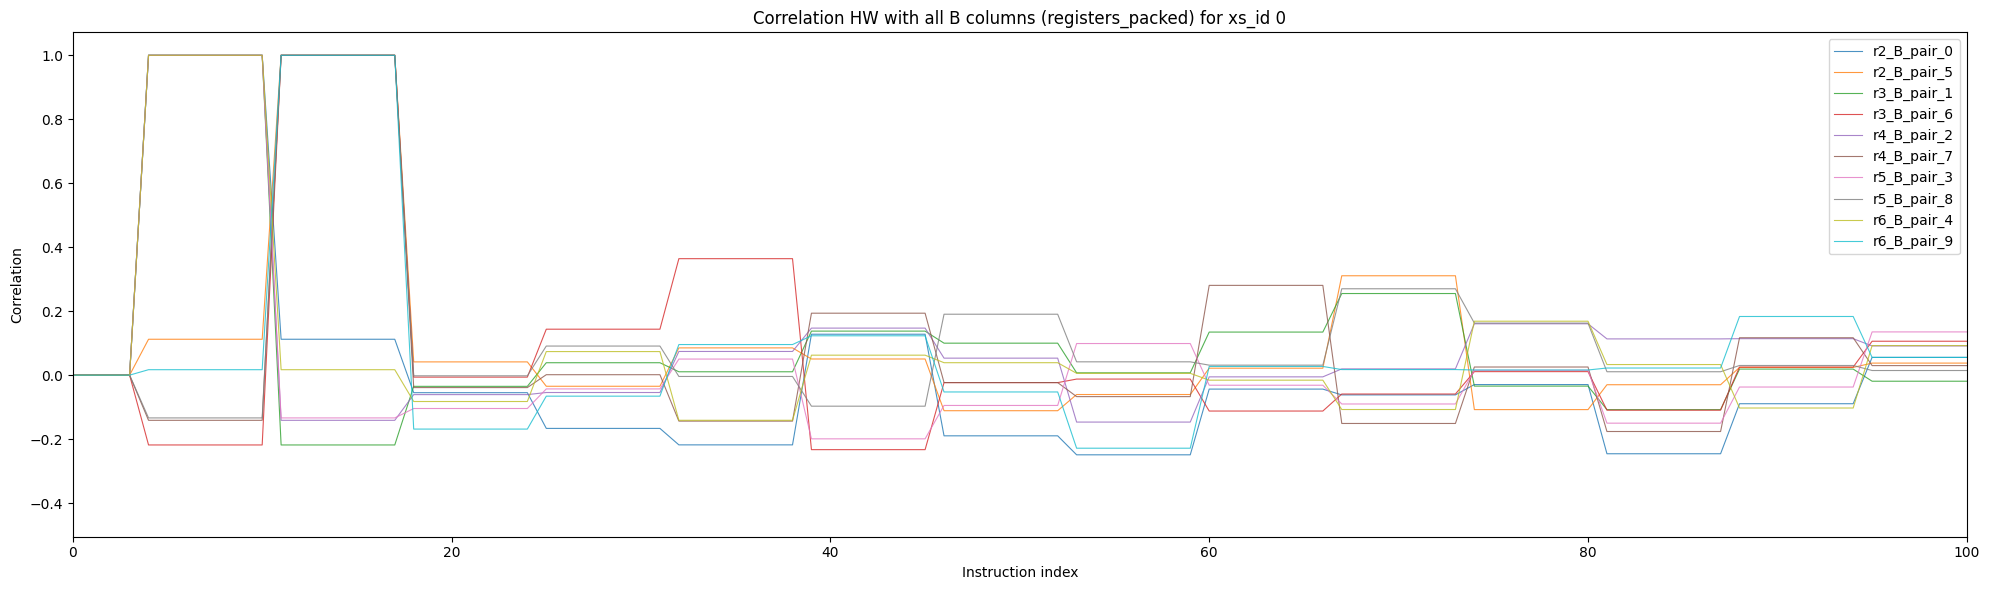

In [5]:
B_folder = Path("output_decapsulation_truncated/B")

B_all, B_runs = load_all_B(B_folder, prefix="B")
B_from_registers, B_register_runs = load_all_B(B_folder, prefix="B_from_registers")
B_packed_from_registers, B_packed_runs = load_all_B(B_folder, prefix="B_from_registers_packed")

print("B_all shape:", B_all.shape)
print("B_from_registers shape:", B_from_registers.shape)
print("B_packed_from_registers shape:", B_packed_from_registers.shape)

xs_id = 0
traces_hw = data_HW_truncated[xs_id]
traces_hd = data_HD_truncated[xs_id]

B_row = xs_id
no_B_cols = 10 

B_base = {
    # "ciphertext": B_all,
    # "registers": B_from_registers,
    "registers_packed": B_packed_from_registers,
}

for B_name, B_values in B_base.items():
    corr_hw_array = {}

    for B_col in range(no_B_cols):
        register_values = B_values[:, B_row, B_col]
        target_hw_values = hw_u32(register_values.astype(np.uint32))

        if B_name == "registers_packed":
            # register index is determined by the column index modulo the number of truncated registers -> look in Ghidra 
            reg_index = B_col % len(truncated_registers)
            reg = truncated_registers[reg_index]

            traces_hw_for_corr = data_HW_by_register[reg][xs_id]
            label = f"{reg}_B_pair_{B_col}"
        else:
            traces_hw_for_corr = traces_hw
            label = f"B_col_{B_col}"

        corr_hw_array[label] = compute_correlation(traces_hw_for_corr,target_hw_values)

    plot_correlation(corr_hw_array,f"Correlation HW with all B columns ({B_name}) for xs_id {xs_id}", os.path.join(result_dir_truncated,f"correlation_HW_all_B_cols_{B_name}_xs{xs_id}.png"),no_instructions=no_instructions)



In [6]:
S_df = pd.read_csv("output_decapsulation_truncated/S/S.csv")
S_real = S_df[[f"S_col_{j}" for j in range(8)]].to_numpy(dtype=np.int16)


Correlation between B[i] * S[i] +  B[i+1] * S[i+1]

In [ ]:
xs_id = 0
B_row = xs_id
no_pairs = 10

traces_hw_r0 = data_HW_r0[xs_id]
traces_hd_r0 = data_HD_r0[xs_id]

B_times_S_base = {
    "ciphertext": B_all,
    # "registers": B_from_registers,
    #"registers_packed": B_packed_from_registers,
}

for B_name, B_values in B_times_S_base.items():
    corr_hw_product_array = {}
    corr_hw_accumulator_array = {}

    r0_old = np.zeros(B_values.shape[0], dtype=np.int32)

    for pair_idx in range(no_pairs):
        B_col = 2 * pair_idx
        B_col_next = B_col + 1

        if B_col_next >= B_values.shape[2]:
            break

        S0 = int(S_real[B_col, xs_id])
        S1 = int(S_real[B_col_next, xs_id])

        pair_product = (
            B_values[:, B_row, B_col].astype(np.int32) * S0
            + B_values[:, B_row, B_col_next].astype(np.int32) * S1
        )

        r0_new = r0_old + pair_product

        target_hw_product = hw_u32(pair_product & 0xffffffff)
        target_hw_accumulator = hw_u32(r0_new & 0xffffffff)
        target_hd_accumulator = hw_u32((r0_old ^ r0_new) & 0xffffffff)

        label = f"pair_{pair_idx}_B{B_col}*S_[{B_col}, {xs_id}]_{B_col_next}*S_[{B_col_next}, {xs_id}]"

        corr_hw_product_array[label] = compute_correlation(traces_hw_r0,target_hw_product)
        corr_hw_accumulator_array[label] = compute_correlation(traces_hw_r0,target_hw_accumulator)

        r0_old = r0_new

    plot_correlation(corr_hw_accumulator_array, f"Correlation HW with actual r0 after B*S ({B_name}) for xs_id {xs_id}",os.path.join(result_dir_truncated,f"correlation_HW_actual_BS_accumulator_{B_name}_xs{xs_id}.png",),no_instructions=no_instructions,)




## Guess S by correlation


In [ ]:
def print_best_guess(corr_array, label, local_sample_idx, real_instruction_idx):
    best_guess = None
    best_abs_corr = -1
    best_corr = None

    for guess_label, corr in corr_array.items():
        guess = int(guess_label.replace("S_", ""))
        corr = np.asarray(corr, dtype=np.float64)

        target_corr = float(corr[local_sample_idx])
        target_abs = abs(target_corr)

        if target_abs > best_abs_corr:
            best_guess = guess
            best_abs_corr = target_abs
            best_corr = target_corr

    print(f"{label} best guess: {best_guess}")
    print(f"{label} abs correlation at target: {best_abs_corr:.6f}")
    print(f"{label} signed correlation at target: {best_corr:.6f}")
    print(f"{label} real instruction index: {real_instruction_idx}")
    return best_guess

Value that we try to guess 

In [ ]:
B_col = 0
B_row = 4
xs_id = 0

S_guesses = range(-10,11)

In [ ]:
if B_col % 2 != 0:
    raise ValueError("B_col must be even because smlad uses pairs: [0,1], [2,3], ...")

B_col_next = B_col + 1
pair_idx = B_col // 2

# Create the actual pair 
S_true = int(S_real[B_col, xs_id])
S_true_next = int(S_real[B_col_next, xs_id])

print("--------------------------------")
print(f"True pair: S[{B_col},{xs_id}] = {S_true}, S[{B_col_next},{xs_id}] = {S_true_next}")

r0_old = np.zeros(B_all.shape[0], dtype=np.int32)

for prev_pair in range(pair_idx):
    k0 = 2 * prev_pair
    k1 = k0 + 1

    r0_old += (
        B_all[:, B_row, k0].astype(np.int32) * int(S_real[k0, xs_id])
        + B_all[:, B_row, k1].astype(np.int32) * int(S_real[k1, xs_id])
    )

trace_df = pd.read_csv(f"output_decapsulation_truncated_TRIM/trace_0_{xs_id}.csv")
trace_df["instruction"] = trace_df["instruction"].astype(str).str.strip().str.lower()

smlad_indices = trace_df.index[trace_df["instruction"] == "smlad"].to_numpy()
smlads_per_xs_call = 320 # 640 // 2 
smlad_global_idx = B_row * smlads_per_xs_call + pair_idx
target_smlad_instruction = int(smlad_indices[smlad_global_idx])

print(f"pair_idx = {pair_idx}")
print(f"smlad_global_idx = {smlad_global_idx}")
print(f"target_smlad_instruction = {target_smlad_instruction}")

instructions_before = 0
instructions_after = 10

hw_target_real = target_smlad_instruction + 1
hd_target_real = target_smlad_instruction

hw_start = max(0, hw_target_real - instructions_before)
traces_hw_r0 = data_HW_r0[xs_id]
traces_hd_r0 = data_HD_r0[xs_id]

hw_end = min(traces_hw_r0.shape[1], hw_target_real + instructions_after + 1)

hd_start = max(0, hd_target_real - instructions_before)
hd_end = min(traces_hd_r0.shape[1], hd_target_real + instructions_after + 1)

traces_hw_guess = traces_hw_r0[:, hw_start:hw_end]
traces_hd_guess = traces_hd_r0[:, hd_start:hd_end]

hw_target_local = hw_target_real - hw_start
hd_target_local = hd_target_real - hd_start

pair_scores = []

for S_guess_0 in S_guesses:
    for S_guess_1 in S_guesses:
        pair_product = (
            B_all[:, B_row, B_col].astype(np.int32) * int(S_guess_0)
            + B_all[:, B_row, B_col_next].astype(np.int32) * int(S_guess_1)
        )

        r0_new = r0_old + pair_product

        target_hw = hw_u32(r0_new & 0xffffffff)
        target_hd = hw_u32((r0_old ^ r0_new) & 0xffffffff)

        corr_hw = compute_correlation(traces_hw_guess, target_hw)
        corr_hd = compute_correlation(traces_hd_guess, target_hd)

        hw_corr = corr_hw[hw_target_local]
        hd_corr = corr_hd[hd_target_local]

        pair_scores.append({
            "S0": S_guess_0,
            "S1": S_guess_1,
            "HW_score": abs(hw_corr),
            "HD_score": abs(hd_corr),
            "HW_corr": hw_corr,
            "HD_corr": hd_corr,
        })

pair_scores_hw = sorted(pair_scores, key=lambda x: x["HW_score"], reverse=True)
pair_scores_hd = sorted(pair_scores, key=lambda x: x["HD_score"], reverse=True)

best_hw = pair_scores_hw[0]
# best_hd = pair_scores_hd[0]

print(f"Best pair HW is: S0 = {best_hw['S0']}, S1 = {best_hw['S1']} with abs correlation {best_hw['HW_score']:.6f}")
# print(f"Best pair HD is: S0 = {best_hd['S0']}, S1 = {best_hd['S1']}")


--------------------------------
True pair: S[0,0] = 3, S[1,0] = -3
pair_idx = 0
smlad_global_idx = 1280
target_smlad_instruction = 1813
Best pair HW is: S0 = 3, S1 = -3 with abs correlation 1.000000


Retrieve the entire col 0 of S based on the correlation

In [ ]:
import os

xs_id = 0
S_guesses = range(-10, 11)

trace_df = pd.read_csv(f"output_decapsulation_truncated_TRIM/trace_0_{xs_id}.csv")
trace_df["instruction"] = trace_df["instruction"].astype(str).str.strip().str.lower()
smlad_indices = trace_df.index[trace_df["instruction"] == "smlad"].to_numpy()

smlads_per_xs_call = 320  # 640 // 2

def retrieve_col_0(b_col, b_row):
    if b_col % 2 != 0:
        raise ValueError("b_col must be even because smlad uses pairs: [0,1], [2,3], ...")

    b_col_next = b_col + 1
    pair_idx = b_col // 2

    S_true = int(S_real[b_col, xs_id])
    S_true_next = int(S_real[b_col_next, xs_id])

    r0_old = np.zeros(B_all.shape[0], dtype=np.int32)

    for prev_pair in range(pair_idx):
        k0 = 2 * prev_pair
        k1 = k0 + 1

        r0_old += (
            B_all[:, b_row, k0].astype(np.int32) * int(S_real[k0, xs_id])
            + B_all[:, b_row, k1].astype(np.int32) * int(S_real[k1, xs_id])
        )

    smlad_global_idx = b_row * smlads_per_xs_call + pair_idx
    target_smlad_instruction = int(smlad_indices[smlad_global_idx])

    instructions_before = 0
    instructions_after = 10

    hw_target_real = target_smlad_instruction + 1
    hd_target_real = target_smlad_instruction

    traces_hw_r0 = data_HW_r0[xs_id]
    traces_hd_r0 = data_HD_r0[xs_id]

    hw_start = max(0, hw_target_real - instructions_before)
    hw_end = min(traces_hw_r0.shape[1], hw_target_real + instructions_after + 1)

    hd_start = max(0, hd_target_real - instructions_before)
    hd_end = min(traces_hd_r0.shape[1], hd_target_real + instructions_after + 1)

    traces_hw_guess = traces_hw_r0[:, hw_start:hw_end]
    traces_hd_guess = traces_hd_r0[:, hd_start:hd_end]

    hw_target_local = hw_target_real - hw_start
    hd_target_local = hd_target_real - hd_start

    pair_scores = []

    for S_guess_0 in S_guesses:
        for S_guess_1 in S_guesses:
            pair_product = (
                B_all[:, b_row, b_col].astype(np.int32) * int(S_guess_0)
                + B_all[:, b_row, b_col_next].astype(np.int32) * int(S_guess_1)
            )

            r0_new = r0_old + pair_product

            target_hw = hw_u32(r0_new & 0xffffffff)
            target_hd = hw_u32((r0_old ^ r0_new) & 0xffffffff)

            corr_hw = compute_correlation(traces_hw_guess, target_hw)
            corr_hd = compute_correlation(traces_hd_guess, target_hd)

            hw_corr = corr_hw[hw_target_local]
            hd_corr = corr_hd[hd_target_local]

            pair_scores.append({
                "S0": S_guess_0,
                "S1": S_guess_1,
                "HW_score": abs(hw_corr),
                "HD_score": abs(hd_corr),
                "HW_corr": hw_corr,
                "HD_corr": hd_corr,
            })

    pair_scores_hw = sorted(pair_scores, key=lambda x: x["HW_score"], reverse=True)
    pair_scores_hd = sorted(pair_scores, key=lambda x: x["HD_score"], reverse=True)

    best_hw = pair_scores_hw[0]
    best_hd = pair_scores_hd[0]

    print (f"b_col={b_col:3}, b_row={b_row}: "
        f"HW best=({best_hw['S0']}, {best_hw['S1']}) "
        f"HW_corr={best_hw['HW_score']:.6f}; "
        f"HD best=({best_hd['S0']}, {best_hd['S1']}) "
        f"HD_corr={best_hd['HD_score']:.6f}; "
        f"true=({S_true}, {S_true_next})"
    )


    return {
        "b_col": b_col,
        "b_row": b_row,
        "S0_guess_hw": best_hw["S0"],
        "S1_guess_hw": best_hw["S1"],
        "S0_guess_hd": best_hd["S0"],
        "S1_guess_hd": best_hd["S1"],
        "S0_true": S_true,
        "S1_true": S_true_next,
        "HW_score": best_hw["HW_score"],
        # "HD_score": best_hd["HD_score"],
        "HW_correct": (best_hw["S0"], best_hw["S1"]) == (S_true, S_true_next),
        # "HD_correct": (best_hd["S0"], best_hd["S1"]) == (S_true, S_true_next),
    }


results = []

for b_col in range(0, B_all.shape[2], 2):
    for b_row in range(B_all.shape[1]):
        result = retrieve_col_0(b_col, b_row)
        results.append(result)
        
        if not result["HW_correct"]:
            print(
                f"HW mismatch for b_col={b_col}, b_row={b_row}: "
                f"guessed ({result['S0_guess_hw']}, {result['S1_guess_hw']}), "
                f"true ({result['S0_true']}, {result['S1_true']})"
            )
            break

results_df = pd.DataFrame(results)
# print the results as a csv file in the Results directory 
results_df.to_csv(f"{result_dir_truncated}/truncated_analysis_results.csv", index=False)


b_col=  0, b_row=0: HW best=(3, -3) HW_corr=1.000000; HD best=(3, -3) HD_corr=1.000000; true=(3, -3)
b_col=  0, b_row=1: HW best=(3, -3) HW_corr=1.000000; HD best=(3, -3) HD_corr=1.000000; true=(3, -3)
b_col=  0, b_row=2: HW best=(3, -3) HW_corr=1.000000; HD best=(3, -3) HD_corr=1.000000; true=(3, -3)
b_col=  0, b_row=3: HW best=(3, -3) HW_corr=1.000000; HD best=(3, -3) HD_corr=1.000000; true=(3, -3)
b_col=  0, b_row=4: HW best=(3, -3) HW_corr=1.000000; HD best=(3, -3) HD_corr=1.000000; true=(3, -3)
b_col=  0, b_row=5: HW best=(3, -3) HW_corr=1.000000; HD best=(3, -3) HD_corr=1.000000; true=(3, -3)
b_col=  0, b_row=6: HW best=(3, -3) HW_corr=1.000000; HD best=(3, -3) HD_corr=1.000000; true=(3, -3)
b_col=  0, b_row=7: HW best=(3, -3) HW_corr=1.000000; HD best=(3, -3) HD_corr=1.000000; true=(3, -3)
b_col=  2, b_row=0: HW best=(0, 1) HW_corr=1.000000; HD best=(0, 1) HD_corr=1.000000; true=(0, 1)
b_col=  2, b_row=1: HW best=(0, 1) HW_corr=1.000000; HD best=(0, 1) HD_corr=1.000000; true=(0,

In [ ]:
# for xs_id in sorted(data_HW_truncated.keys()):
#     print(f"Plotting xs_id = {xs_id}")
#     plot_hw_hd_comparison(
#         data_HW_truncated[xs_id],
#         data_HD_truncated[xs_id],
#         title=f"HW vs HD comparison for xs = {xs_id}",
#         save_path=os.path.join(result_dir_truncated, f"hw_hd_comparison_xs{xs_id}.png"),
#         max_traces=None,
#     )
